# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 62     |  |
| :-------------|:-------------|
| Student Thijn Holswilder | 6536387 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['naam1', 'naam2','naam3']

## Opdracht 1: Planning.

| Planning Groep: XX     |Tijdstip / Tijdspanne  |
|---|---|
| Mijlpaal 1 | Tijdstip |
| Mijlpaal 2 | Tijdstip |
| groep aanwezig 1| Tijdspanne |
| groep aanwezig 2| Tijdspanne |
| Pauze 1| Tijdspanne |
| Pauze 2| Tijdspanne |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [62]
<img src="opstelling-kalibreren-subwoofer.jpeg" width="400">

a = 0.0339 ± 0.0002
b = -0.04 ± 0.24


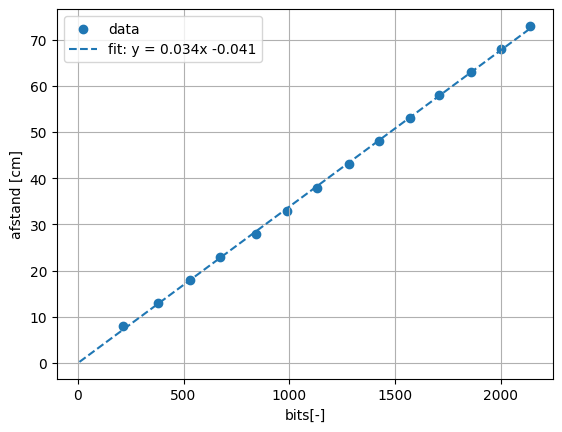

In [3]:
# Data
afstand = (90 - np.array([82, 77, 72, 67, 62, 57, 52, 47, 42, 37, 32, 27, 22, 17]))  # [cm]
bits = np.array([215, 380, 532, 673, 845, 988, 1133, 1284, 1423, 1570, 1707, 1860, 2000, 2140])

# Lineair model
def f(x, a, b):
    return a*x + b

# Fit
popt, pcov = curve_fit(f, bits, afstand)

a, b = popt
ua, ub = np.sqrt(np.diag(pcov))

print(f"a = {a:.4f} ± {ua:.4f}")
print(f"b = {b:.2f} ± {ub:.2f}")

# Fijne x voor plot
x_fit = np.linspace(min(afstand), max(bits), 100)
y_fit = f(x_fit, a, b)

# Plot
plt.figure()
plt.scatter(bits, afstand, label="data")
plt.plot(x_fit, y_fit, '--', label=f"fit: y = {a:.3f}x {b:.3f}")
plt.xlabel("bits[-]")
plt.ylabel("afstand [cm]")
plt.legend()
plt.grid()
plt.show()

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0   0  40   0  30  41
1   0  30   0  20  41
2  40   0  30   0  41
3  30   0  20   0  41


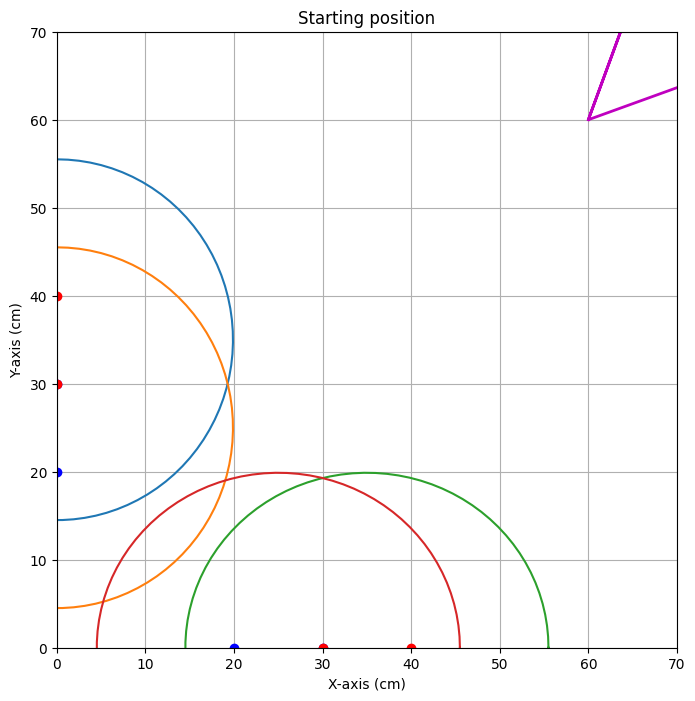


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=100.955


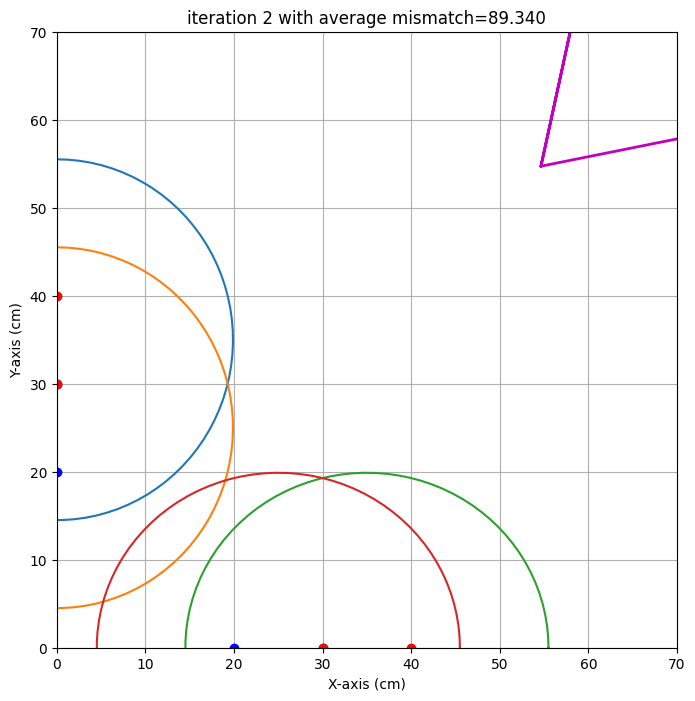

end iteration 2 with average mismatch=89.340


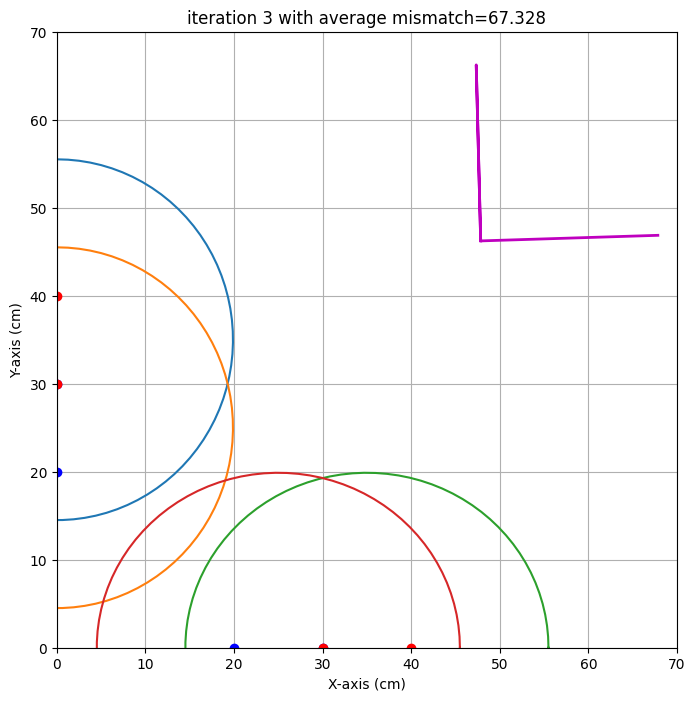

end iteration 3 with average mismatch=67.328


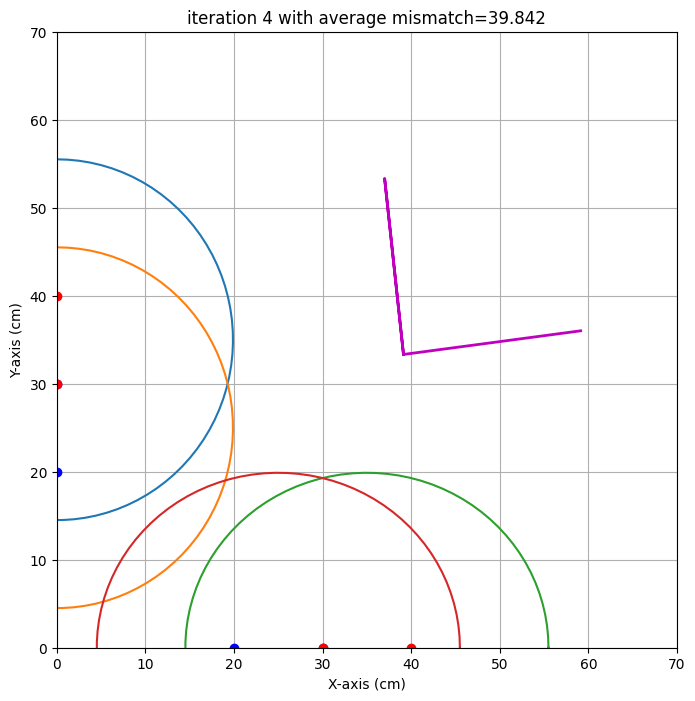

end iteration 4 with average mismatch=39.842


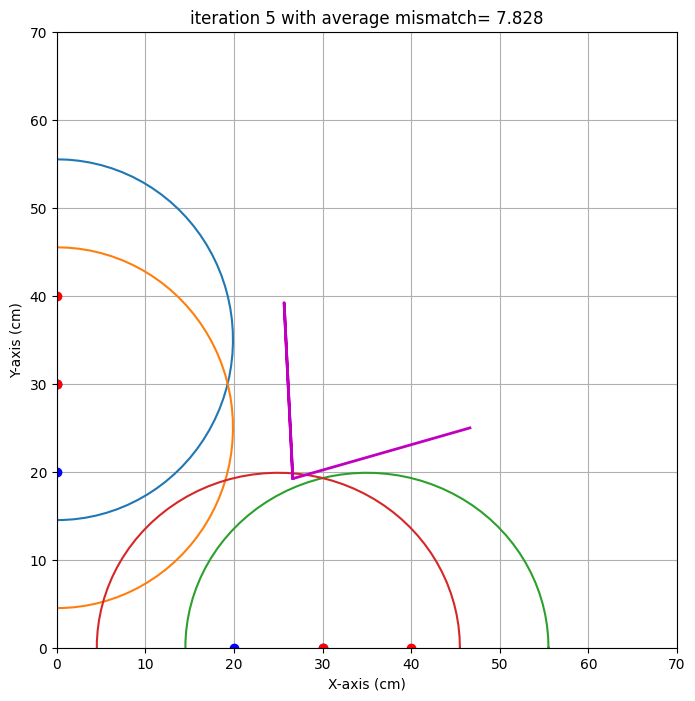

end iteration 5 with average mismatch= 7.828


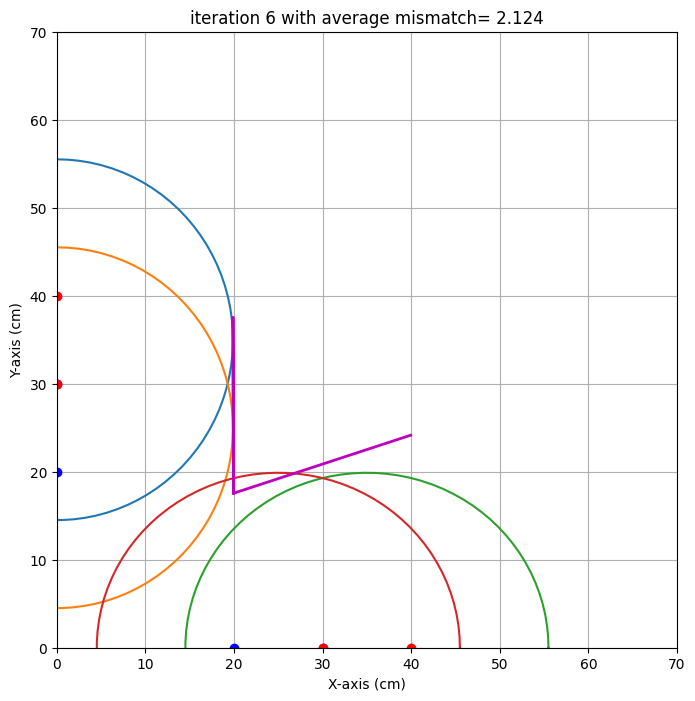

end iteration 6 with average mismatch= 2.124


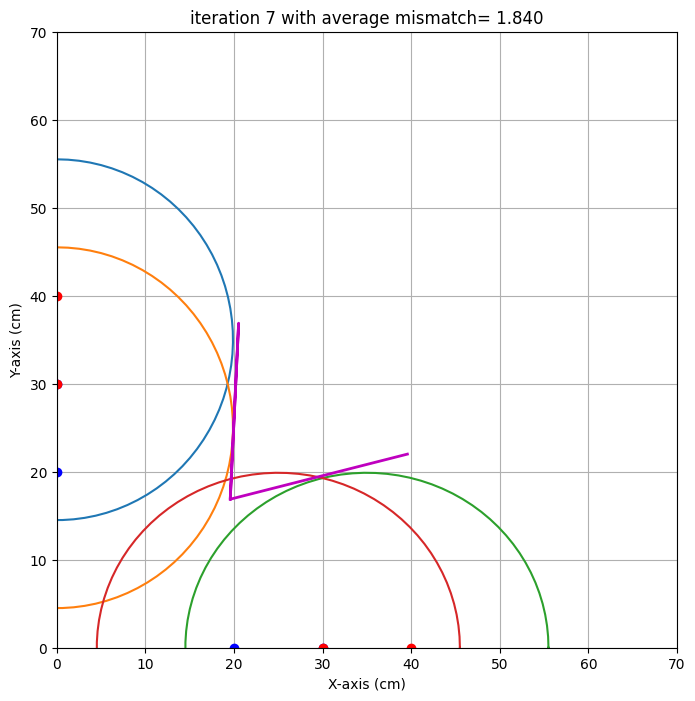

end iteration 7 with average mismatch= 1.840


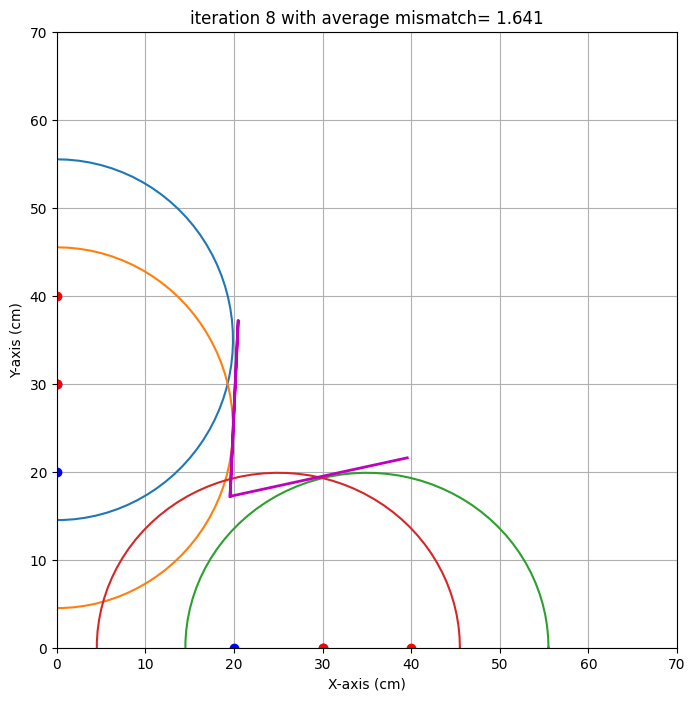

end iteration 8 with average mismatch= 1.641
end iteration 9 with average mismatch= 1.563
end iteration 10 with average mismatch= 1.480


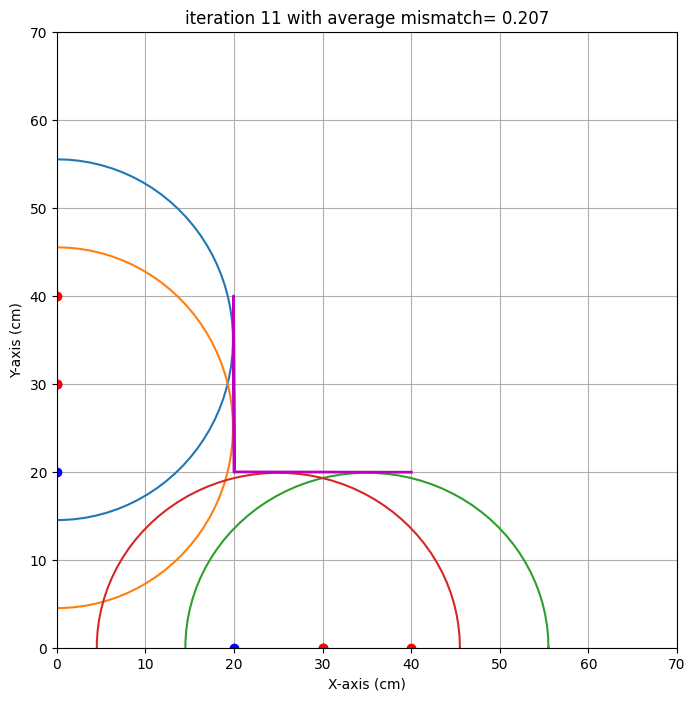

end iteration 11 with average mismatch= 0.207


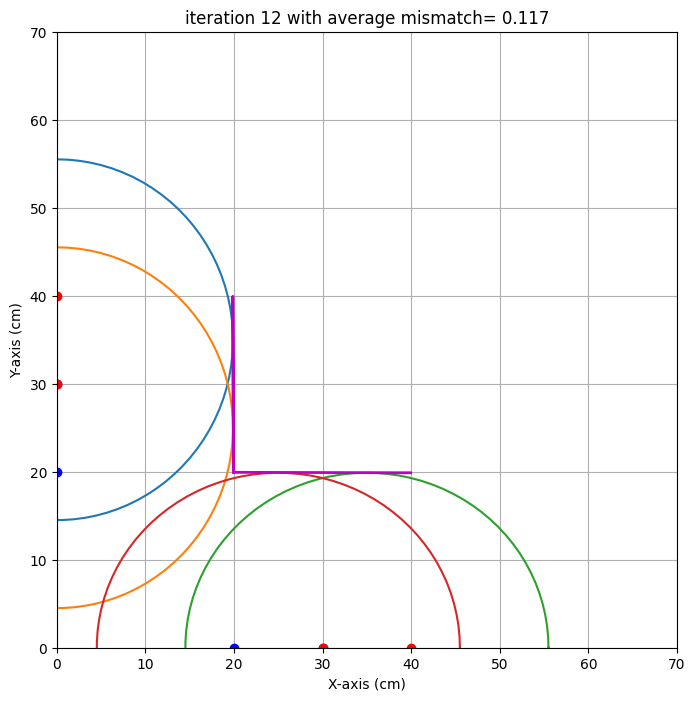

end iteration 12 with average mismatch= 0.117
end iteration 13 with average mismatch= 0.114
end iteration 14 with average mismatch= 0.113
end iteration 15 with average mismatch= 0.113
end iteration 16 with average mismatch= 0.113
end iteration 17 with average mismatch= 0.113
end iteration 18 with average mismatch= 0.113
end iteration 19 with average mismatch= 0.113
end iteration 20 with average mismatch= 0.113
end iteration 21 with average mismatch= 0.113
end iteration 22 with average mismatch= 0.113
end iteration 23 with average mismatch= 0.113
end iteration 24 with average mismatch= 0.113
end iteration 25 with average mismatch= 0.113
end iteration 26 with average mismatch= 0.113
end iteration 27 with average mismatch= 0.113
end iteration 28 with average mismatch= 0.113
end iteration 29 with average mismatch= 0.113
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.113
#################

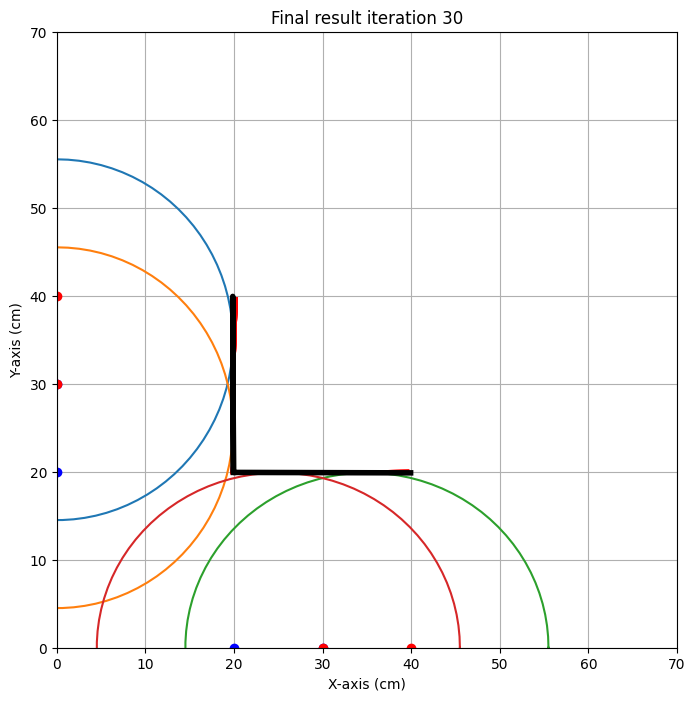

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41],
    [0,30,0,20,41],
    #[0,10,0,20,260],
    [40,0,30,0,41],
    [30,0,20,0,41],
    #[10,0,20,0,260],
    #[10,0,0,10,260]    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.9 cm met een standaardafwijking van 0.2 cm 
y0: 19.9 cm met een standaardafwijking van 0.1 cm 
alpha: -0.1 graden met een standaardafwijking van 1.3 graad 
beta: -0.2 graden met een standaardafwijking van 2.1 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Thijn Holswilder]
Voeg een foto in van het algoritme van het enigste groepslid
<img src="algoritme1-schets.jpeg" width="400">


## Opdracht 6: Test iteratie 0.

### simpele eigen geschreven algortime

In [6]:
import numpy as np

threshold = 50

xr = np.arange(0, 35, 5)
xs = xr + 10
x_mid = (xr + xs) / 2

R_x = np.array([170, 170, 170, 41, 41, 41, 41]) / 2

links = 0
rechts = 40

for i in range(len(x_mid)):
    if R_x[i] < threshold:
        if x_mid[i] < rechts:
            rechts = x_mid[i]
    else:
        if x_mid[i] > links:
            links = x_mid[i]

x0 = (links + rechts) / 2
print("x0 =", x0)



yr = np.arange(0, 30, 5) 
ys = yr + 10
y_mid = (yr + ys) / 2

R_y = np.array([170, 170, 170, 41, 41, 41, 41]) / 2

onder = 0
boven = 40

for i in range(len(y_mid)):
    if R_y[i] < threshold:
        if y_mid[i] < boven:
            boven = y_mid[i]
    else:
        if y_mid[i] > onder:
            onder = y_mid[i]

y0 = (onder + boven) / 2
print("y0 =", y0)

import numpy as np

R_alpha =  41 /2
R_beta =   41 /2

x_max = 40
y_max = 40

alpha = np.rad2deg(np.arctan((R_alpha - y0) / (y_max - x0)))
beta  = np.rad2deg(np.arctan((R_beta  - x0) / (x_max - y0)))

print("alpha =", alpha)
print("beta =", beta)


x0 = 17.5
y0 = 17.5
alpha = 7.594643368591445
beta = 7.594643368591445


In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 20,  #zelf aanvullen,
           'y0': 20,  #zelf aanvullen,
           'alpha' : 0, #zelf aanvullen,
           'beta' : 0 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Thijn Holswilder' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
            # [10,0,0,0,170],
            # [15,0,5,0,170],
            # [20,0,10,0,170],
            [25,0,15,0,41],
            [30,0,20,0,41],
            [35,0,25,0,41],
            [40,0,30,0,41],

            # [0,10,0,0,170],
            # [0,15,0,5,170],
            # [0,20,0,10,170],
            [0,25,0,15,41],
            [0,30,0,20,41],
            [0,35,0,25,41],
            [0,40,0,30,41]
        ]
)
}

## Opdracht 7: Evaluatie.

Running the imaging algorithm with the following data:
   xs  ys  xr  yr   R
0  25   0  15   0  41
1  30   0  20   0  41
2  35   0  25   0  41
3  40   0  30   0  41
4   0  25   0  15  41
5   0  30   0  20  41
6   0  35   0  25  41
7   0  40   0  30  41


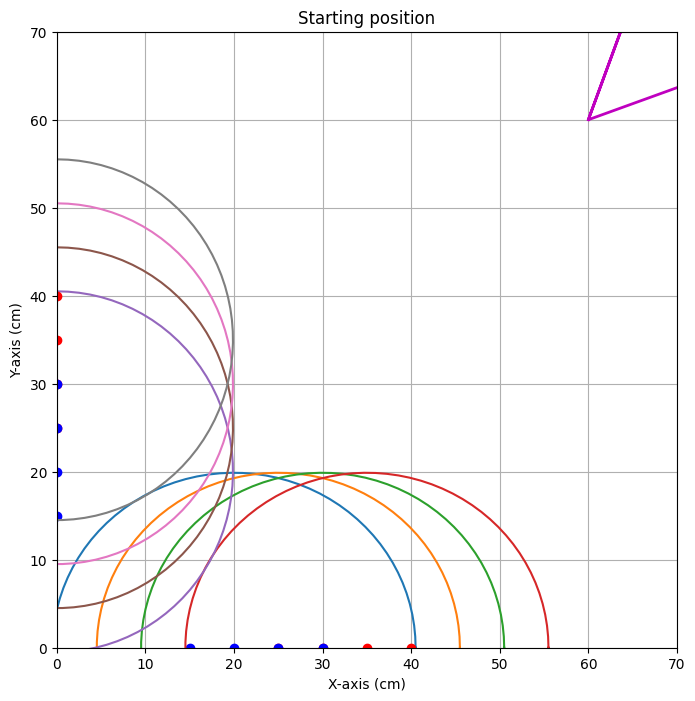


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=103.381


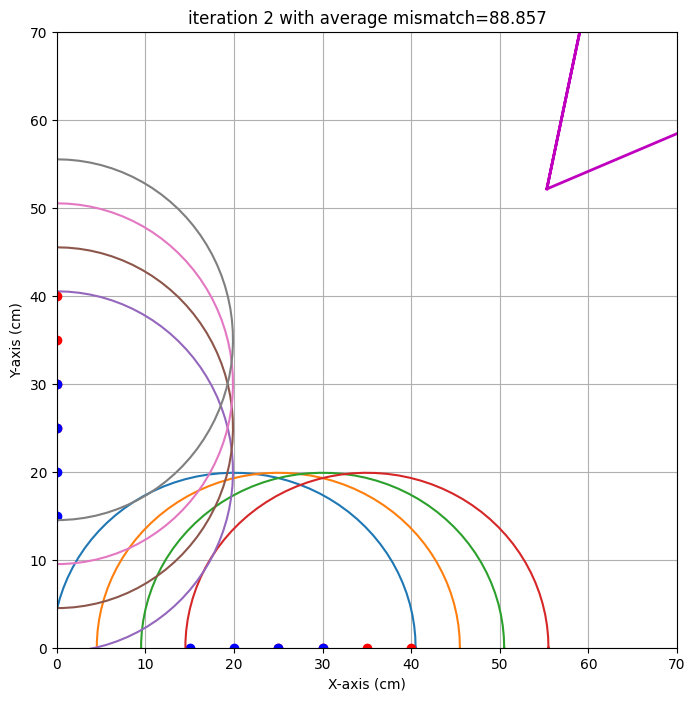

end iteration 2 with average mismatch=88.857


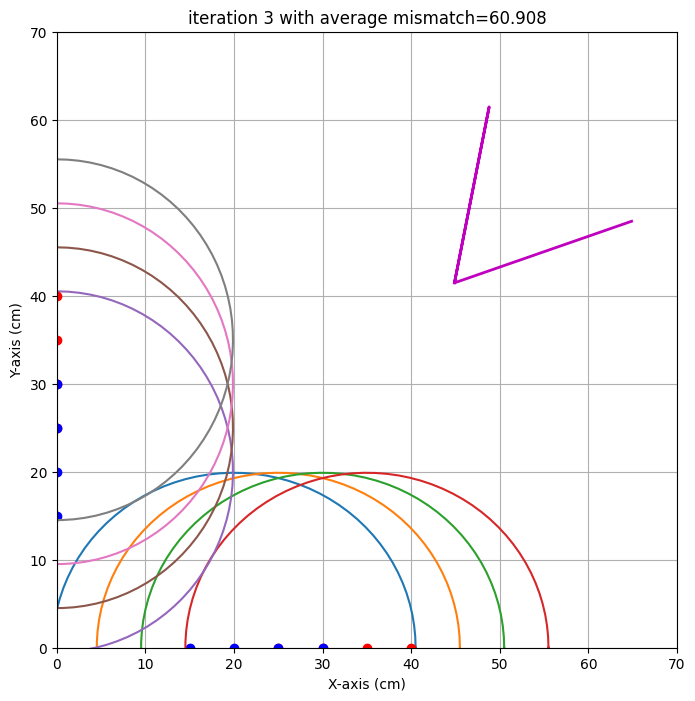

end iteration 3 with average mismatch=60.908


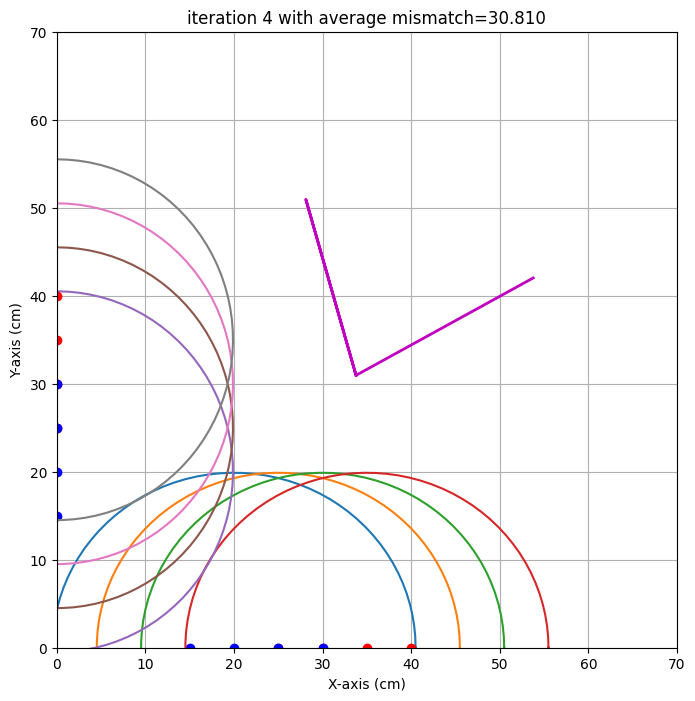

end iteration 4 with average mismatch=30.810


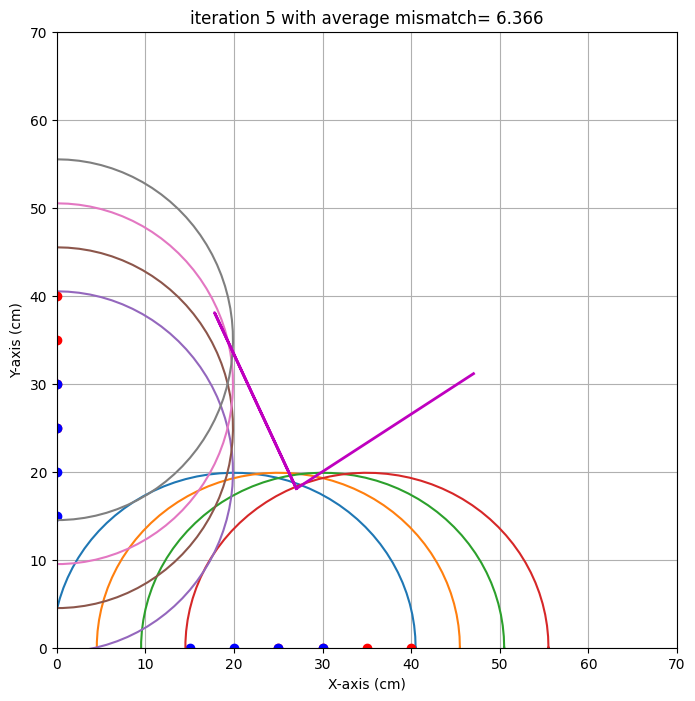

end iteration 5 with average mismatch= 6.366
end iteration 6 with average mismatch= 6.257
end iteration 7 with average mismatch= 5.894
end iteration 8 with average mismatch= 5.883


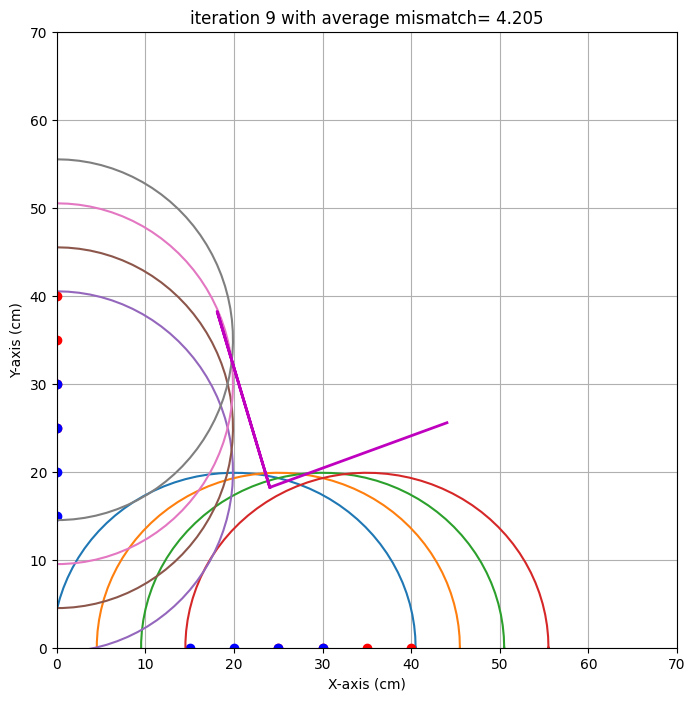

end iteration 9 with average mismatch= 4.205


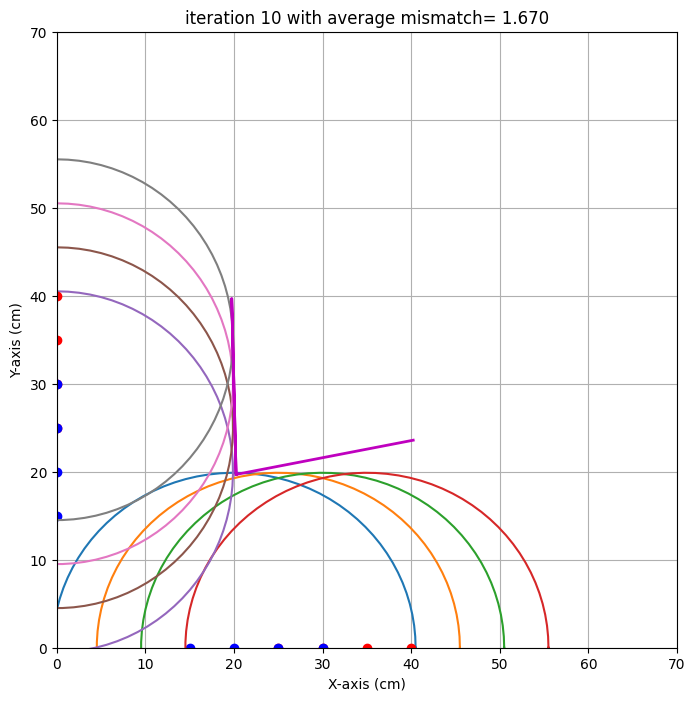

end iteration 10 with average mismatch= 1.670


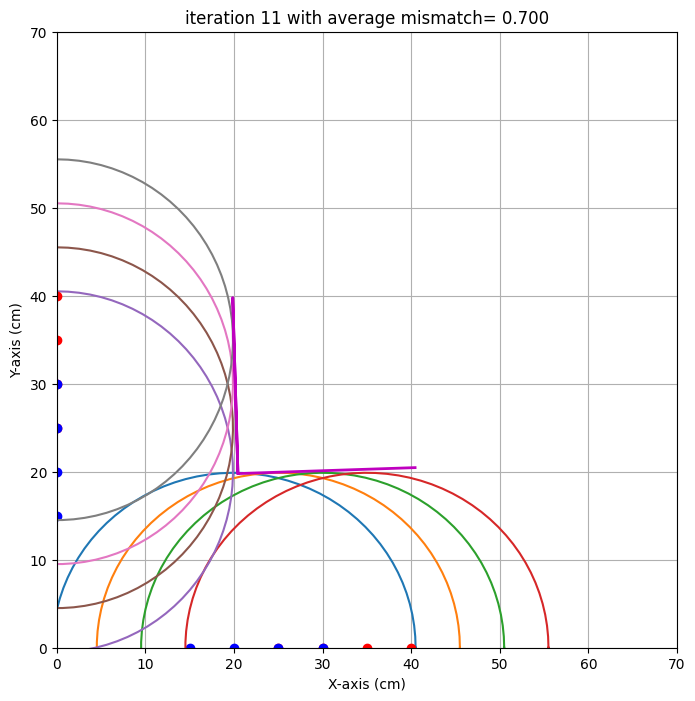

end iteration 11 with average mismatch= 0.700


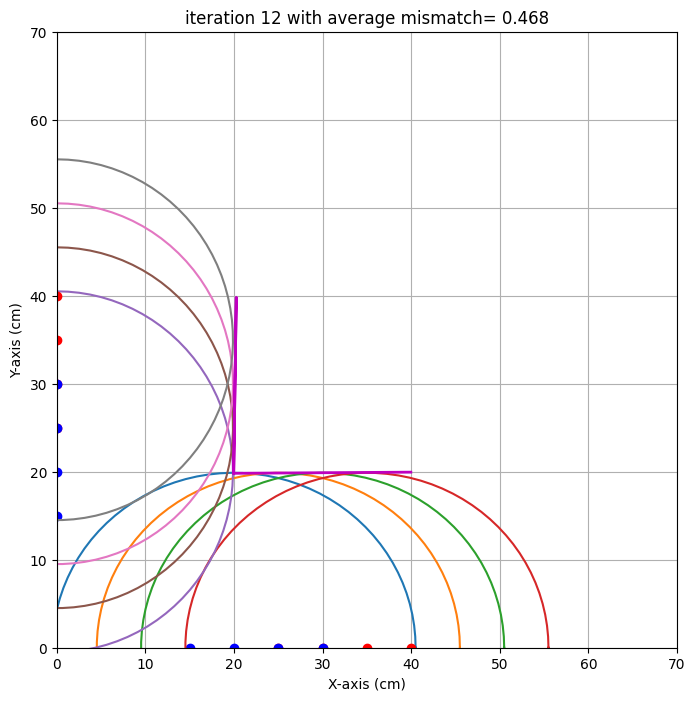

end iteration 12 with average mismatch= 0.468
end iteration 13 with average mismatch= 0.466
end iteration 14 with average mismatch= 0.466
end iteration 15 with average mismatch= 0.466
end iteration 16 with average mismatch= 0.466
end iteration 17 with average mismatch= 0.466
end iteration 18 with average mismatch= 0.466
end iteration 19 with average mismatch= 0.466
end iteration 20 with average mismatch= 0.466
end iteration 21 with average mismatch= 0.466
end iteration 22 with average mismatch= 0.466
end iteration 23 with average mismatch= 0.456
end iteration 24 with average mismatch= 0.431
end iteration 25 with average mismatch= 0.427
end iteration 26 with average mismatch= 0.427
end iteration 27 with average mismatch= 0.427
end iteration 28 with average mismatch= 0.427
end iteration 29 with average mismatch= 0.427
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration

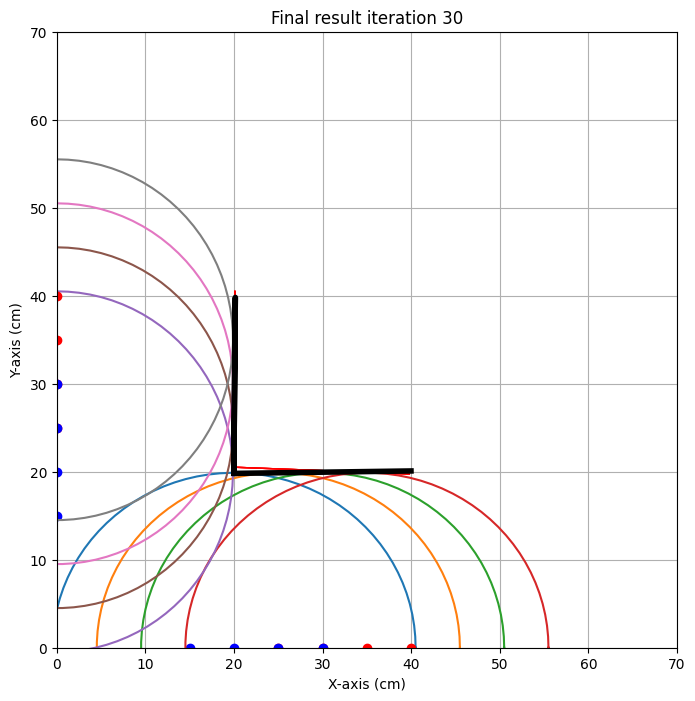

{'alpha': np.float64(0.7952975082094207), 'alpha_eps': np.float64(3.023751462980732), 'beta': np.float64(0.4762499854018262), 'beta_eps': np.float64(0.399684160992053), 'x0': np.float64(19.977217579379314), 'x0_eps': np.float64(0.18423308908496594), 'y0': np.float64(19.809351169927123), 'y0_eps': np.float64(0.7121406942850399)}


In [8]:
# Hier runnen we het imaging algoritme:

resultaat = imagingDEF.imagingDEF(data['Thijn Holswilder'])
print(resultaat)


In [9]:
studentName = 'Thijn Holswilder'

txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt += 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt += 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt += 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'

print(txt.format(
    naam=studentName,
    x0Target=targets['x0'],
    x0=resultaat['x0'],
    x0_eps=resultaat['x0_eps'],
    y0Target=targets['y0'],
    y0=resultaat['y0'],
    y0_eps=resultaat['y0_eps'],
    alphaTarget=targets['alpha'],
    alpha=resultaat['alpha'],
    alpha_eps=resultaat['alpha_eps'],
    betaTarget=targets['beta'],
    beta=resultaat['beta'],
    beta_eps=resultaat['beta_eps']
))

Thijn Holswilder 
x0 target is : 20.0. Gevonden waarde: 20.0 cm met een standaardafwijking van 0.2 cm 
y0 target is : 20.0. Gevonden waarde: 19.8 cm met een standaardafwijking van 0.7 cm 
alpha target is : 0.0. Gevonden waarde: 0.8 graden met een standaardafwijking van 3.0 graad 
beta target is : 0.0. Gevonden waarde: 0.5 graden met een standaardafwijking van 0.4 graad 



In [10]:
studentName = 'Thijn Holswilder'

txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt += 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt += 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt += 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'

print(txt.format(
    naam=studentName,
    x0Target=targets['x0'],
    x0=resultaat['x0'],
    x0_eps=resultaat['x0_eps'],
    y0Target=targets['y0'],
    y0=resultaat['y0'],
    y0_eps=resultaat['y0_eps'],
    alphaTarget=targets['alpha'],
    alpha=resultaat['alpha'],
    alpha_eps=resultaat['alpha_eps'],
    betaTarget=targets['beta'],
    beta=resultaat['beta'],
    beta_eps=resultaat['beta_eps']
))

Thijn Holswilder 
x0 target is : 20.0. Gevonden waarde: 20.0 cm met een standaardafwijking van 0.2 cm 
y0 target is : 20.0. Gevonden waarde: 19.8 cm met een standaardafwijking van 0.7 cm 
alpha target is : 0.0. Gevonden waarde: 0.8 graden met een standaardafwijking van 3.0 graad 
beta target is : 0.0. Gevonden waarde: 0.5 graden met een standaardafwijking van 0.4 graad 



## Opdracht 8: Iteratie1+.tijd komt niet overeen met de dag van de opdracht voor mij.
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](algoritme2-schets.jpeg)


## Opdracht 9: Iteratie 1+ meeting en test

In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0': 37 ,  #zelf aanvullen,
           'y0': 45,  #zelf aanvullen,
           'alpha' : 7, #zelf aanvullen,
           'beta' : 4 #zelf aanvullen},
          }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data1 ={'Thijn Holswilder' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
            [0,60,0,50,75.76],
            [0,50,0,40,76.30],
            [0,55,0,45,75.12],
            #[0,40,0,30,200],

            [60,0,50,0,94.17],
            [50,0,40,0,92.30]
            #[40,0,30,0,200]
]
)
}

Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  60   0  50  75.76
1   0  50   0  40  76.30
2   0  55   0  45  75.12
3  60   0  50   0  94.17
4  50   0  40   0  92.30


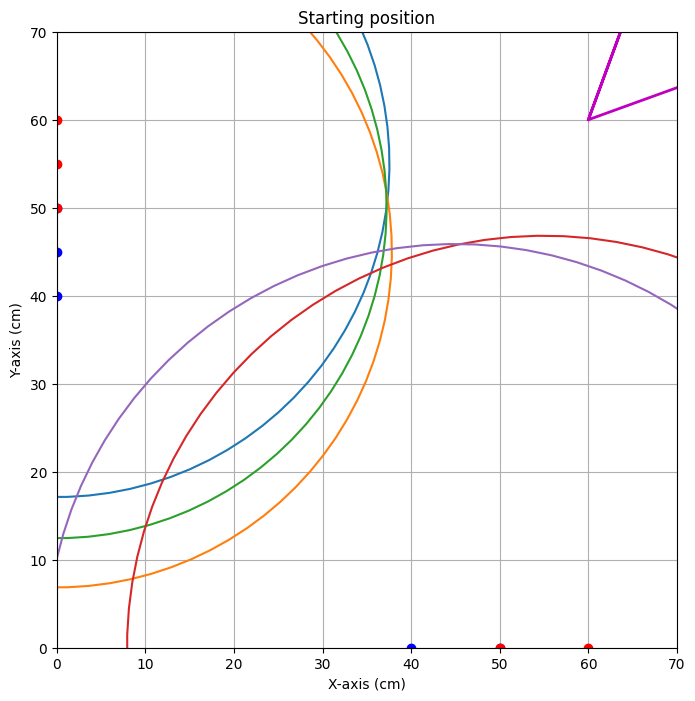


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=45.136


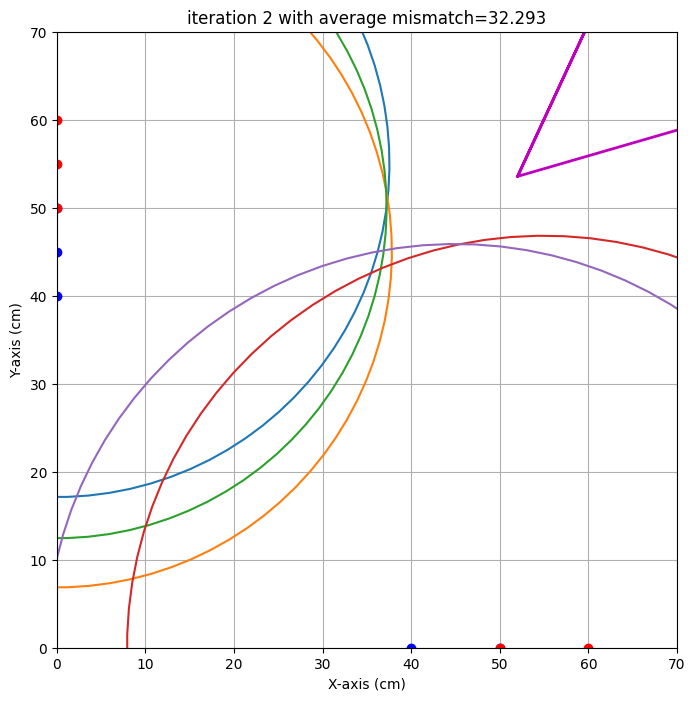

end iteration 2 with average mismatch=32.293


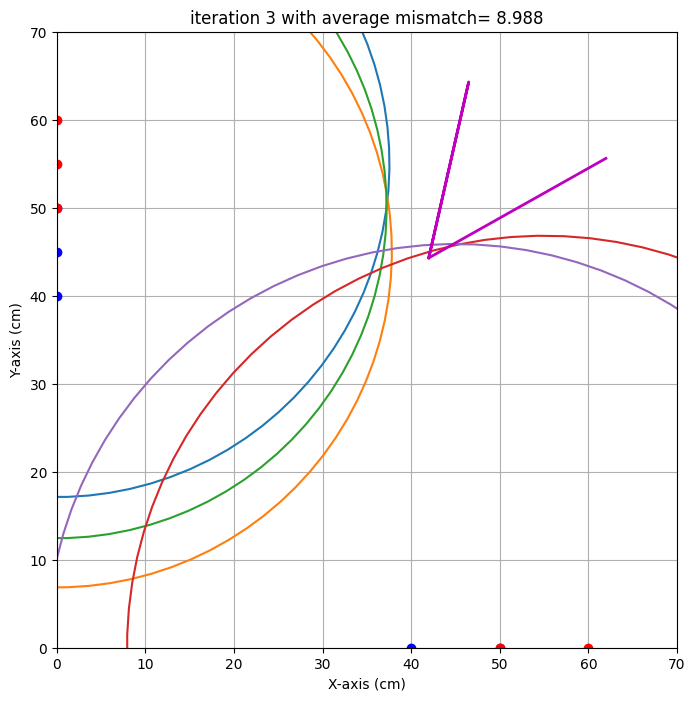

end iteration 3 with average mismatch= 8.988


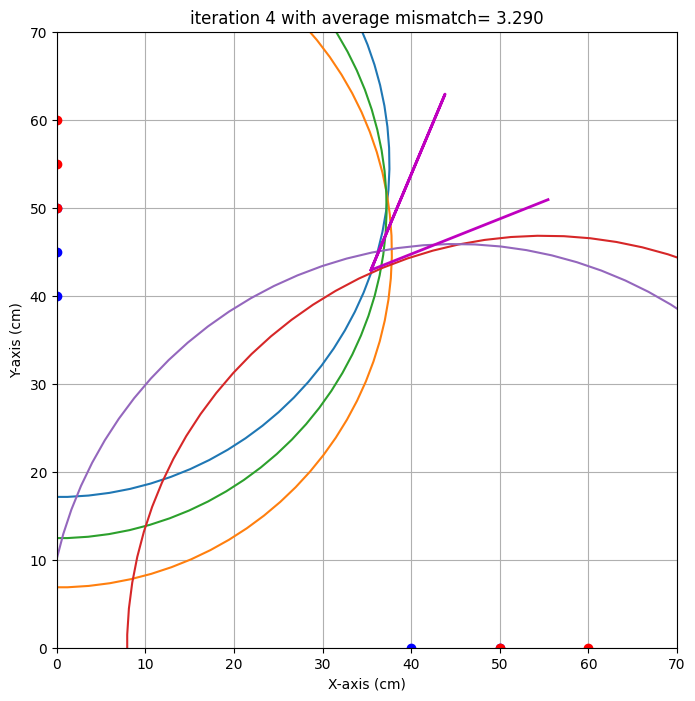

end iteration 4 with average mismatch= 3.290


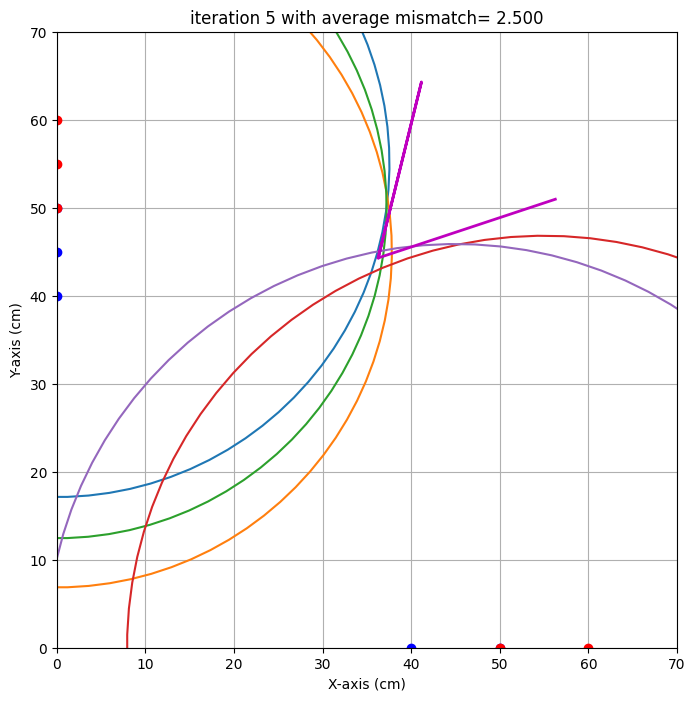

end iteration 5 with average mismatch= 2.500


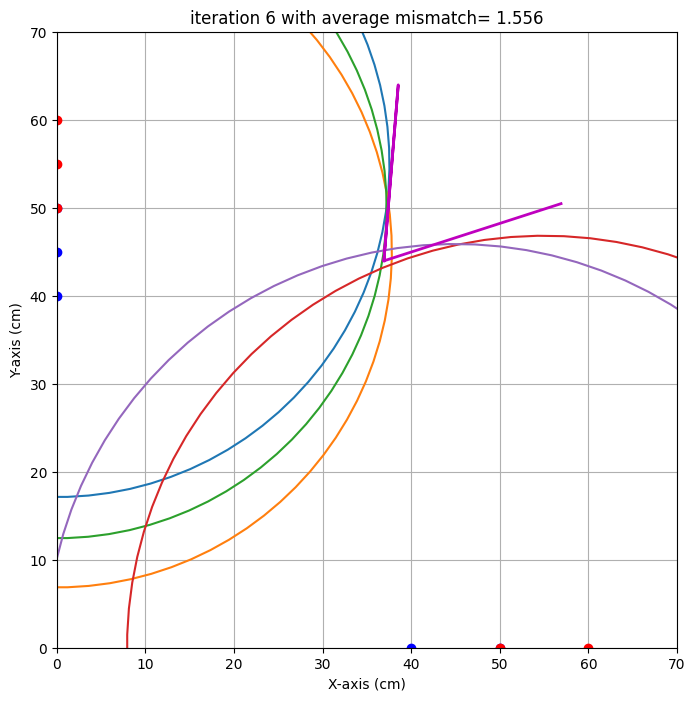

end iteration 6 with average mismatch= 1.556


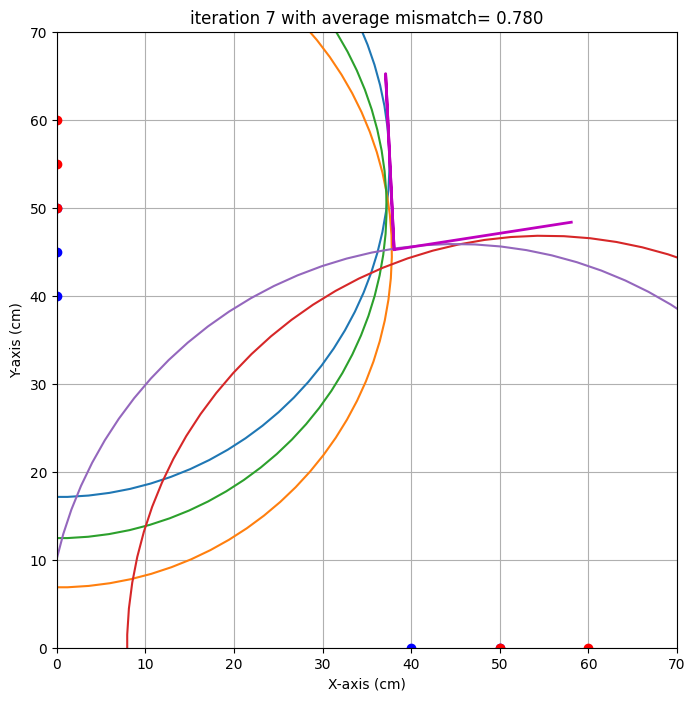

end iteration 7 with average mismatch= 0.780
end iteration 8 with average mismatch= 0.758


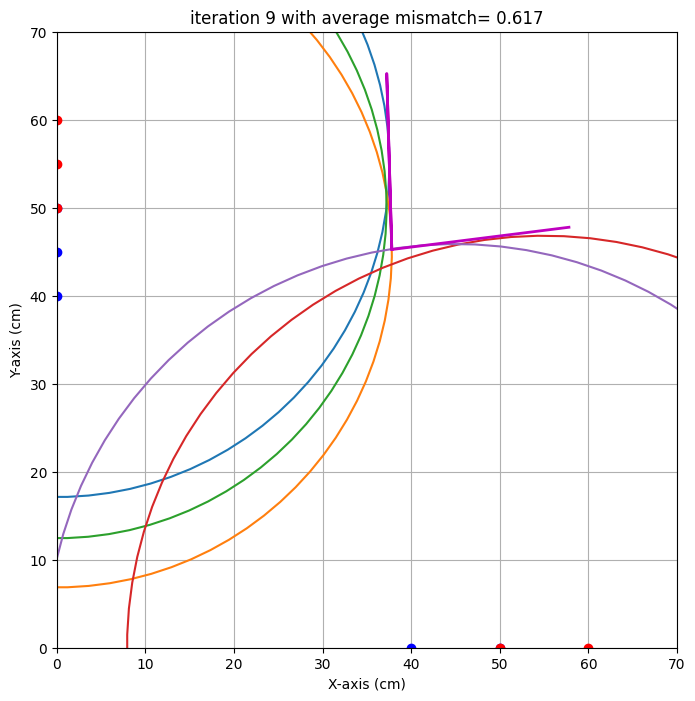

end iteration 9 with average mismatch= 0.617


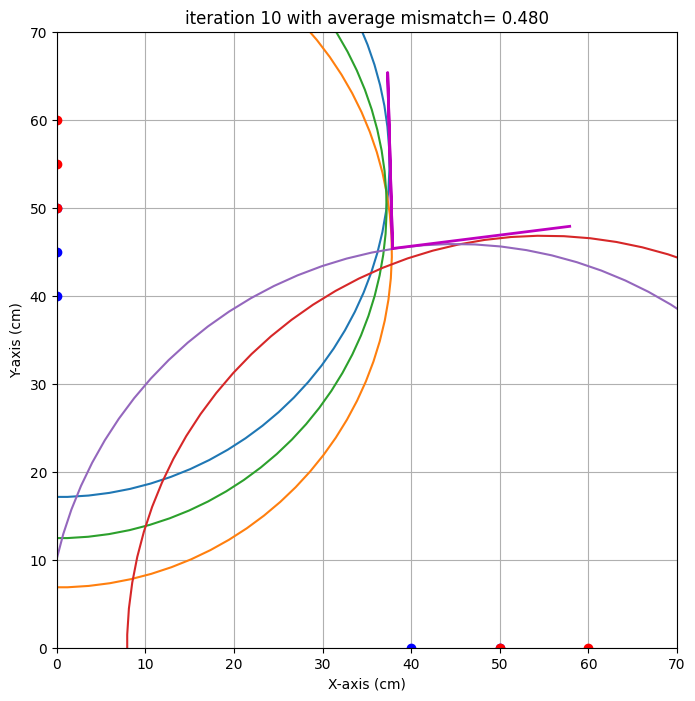

end iteration 10 with average mismatch= 0.480
end iteration 11 with average mismatch= 0.440
end iteration 12 with average mismatch= 0.409
end iteration 13 with average mismatch= 0.393
end iteration 14 with average mismatch= 0.390
end iteration 15 with average mismatch= 0.390
end iteration 16 with average mismatch= 0.390
end iteration 17 with average mismatch= 0.390
end iteration 18 with average mismatch= 0.390
end iteration 19 with average mismatch= 0.390
end iteration 20 with average mismatch= 0.390
end iteration 21 with average mismatch= 0.390
end iteration 22 with average mismatch= 0.390
end iteration 23 with average mismatch= 0.390
end iteration 24 with average mismatch= 0.390
end iteration 25 with average mismatch= 0.390
end iteration 26 with average mismatch= 0.390
end iteration 27 with average mismatch= 0.390
end iteration 28 with average mismatch= 0.390
end iteration 29 with average mismatch= 0.390
Last iteration, also determine uncertainty, wait a while..
wait a little longer.

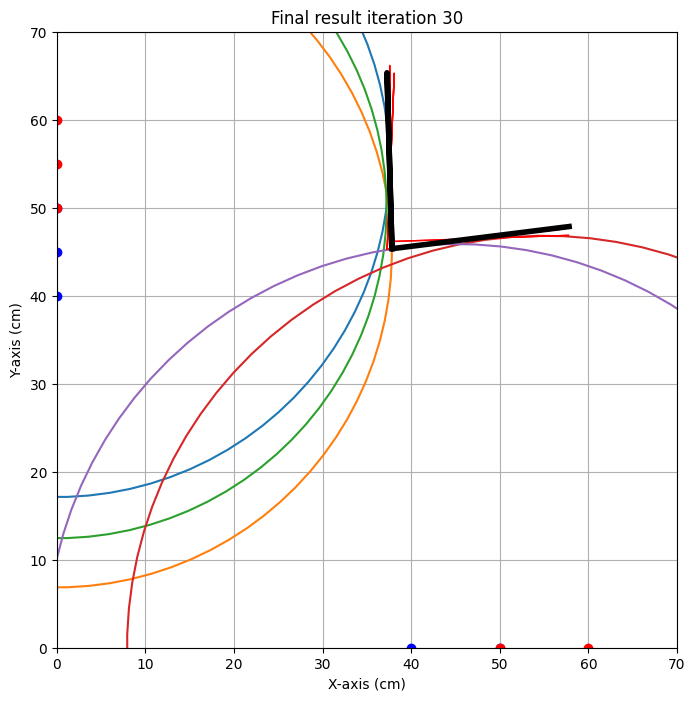

{'alpha': np.float64(7.175840647288898), 'alpha_eps': np.float64(5.163693725268347), 'beta': np.float64(-1.5988182615707294), 'beta_eps': np.float64(3.8881626372150784), 'x0': np.float64(37.82907827195198), 'x0_eps': np.float64(0.5384142476104259), 'y0': np.float64(45.342244678710586), 'y0_eps': np.float64(0.8171029223373694)}


In [12]:
resultaat = imagingDEF.imagingDEF(data1['Thijn Holswilder'])
print(resultaat)

In [13]:
studentName = 'Thijn Holswilder'

txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt += 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt += 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt += 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'

print(txt.format(
    naam=studentName,
    x0Target=targets['x0'],
    x0=resultaat['x0'],
    x0_eps=resultaat['x0_eps'],
    y0Target=targets['y0'],
    y0=resultaat['y0'],
    y0_eps=resultaat['y0_eps'],
    alphaTarget=targets['alpha'],
    alpha=resultaat['alpha'],
    alpha_eps=resultaat['alpha_eps'],
    betaTarget=targets['beta'],
    beta=resultaat['beta'],
    beta_eps=resultaat['beta_eps']
))

Thijn Holswilder 
x0 target is : 37.0. Gevonden waarde: 37.8 cm met een standaardafwijking van 0.5 cm 
y0 target is : 45.0. Gevonden waarde: 45.3 cm met een standaardafwijking van 0.8 cm 
alpha target is : 7.0. Gevonden waarde: 7.2 graden met een standaardafwijking van 5.2 graad 
beta target is : 4.0. Gevonden waarde: -1.6 graden met een standaardafwijking van 3.9 graad 



## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

In [14]:
#omdat ik geen TA heb om dit te controleren doen we het alsvolgd:
import random

random.seed(69)
print(f'x0 = {random.randint(0, 30) + 20}')
random.seed(67)
print(f'y0 = {random.randint(0, 30) + 20}')
random.seed(6969)
print(f'alpha = {random.randint(0, 30) - 15}')
random.seed(6767)
print(f'beta = {random.randint(0, 30) - 15}')

# ik zal proberen de hoek en (x0,y0) zo nauwkeurig mogelijk neer te zetten 

x0 = 41
y0 = 22
alpha = -13
beta = 6


#### Laatste definitieve algoritme dus eigelijk iteratie 2

Figuur: ![Alt](algoritme3-schets.jpeg)

In [15]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'x0': 41, # zelf aanvullen,
            'y0': 22, # zelf aanvullen,
            'alpha' : -13, # zelf aanvullen,
            'beta' : 6 # zelf aanvullen
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'Thijn Holswilder' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
            #[0,60,0,50,200],
            [0,50,0,40,84.50],
            [0,40,0,30,82.70],
            [0,45,0,35,82.50],

            [60,0,50,0,42.10],
            [50,0,40,0,44.60],
            [55,0,45,0,43.50]
            #[40,0,30,0,200]
]
)
}

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  50   0  40  84.5
1   0  40   0  30  82.7
2   0  45   0  35  82.5
3  60   0  50   0  42.1
4  50   0  40   0  44.6
5  55   0  45   0  43.5


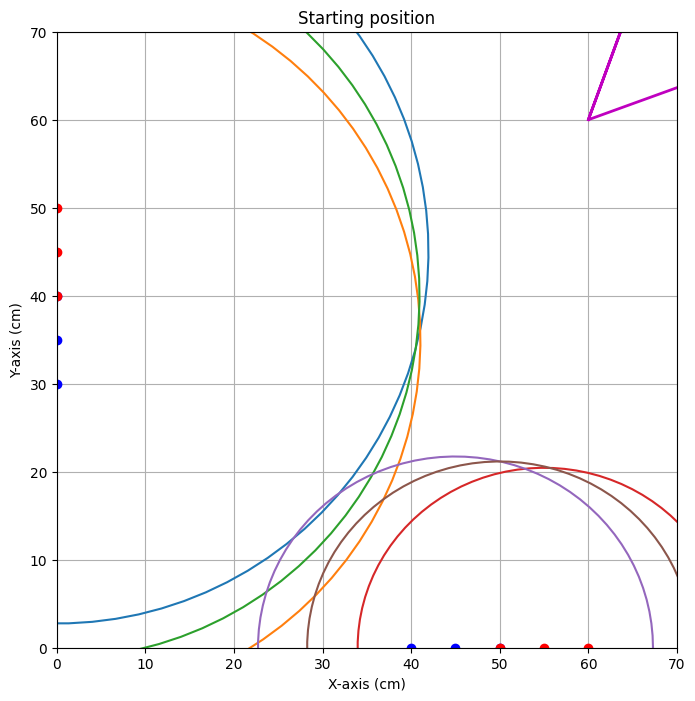


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=68.166


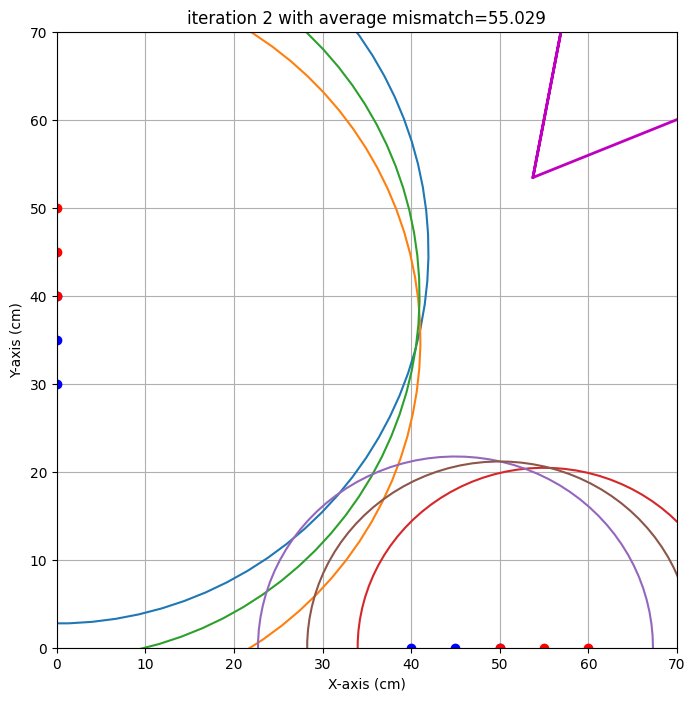

end iteration 2 with average mismatch=55.029


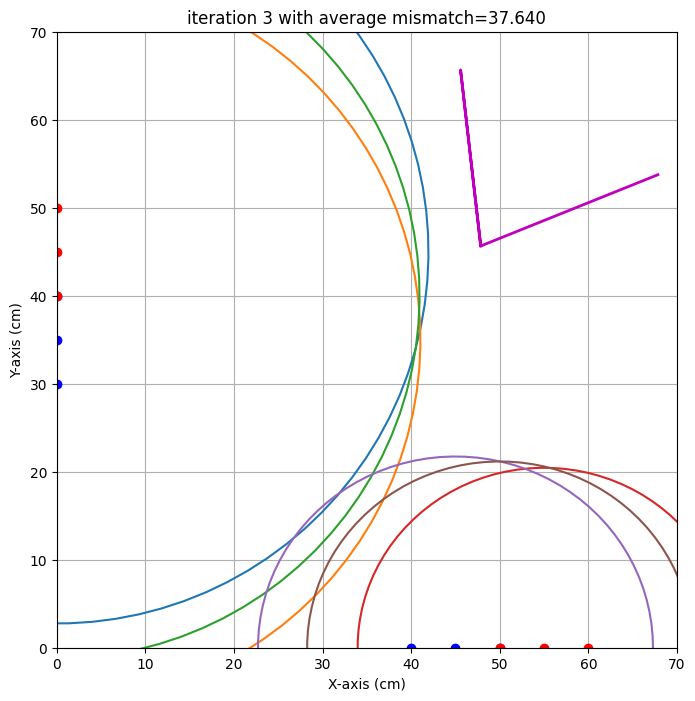

end iteration 3 with average mismatch=37.640


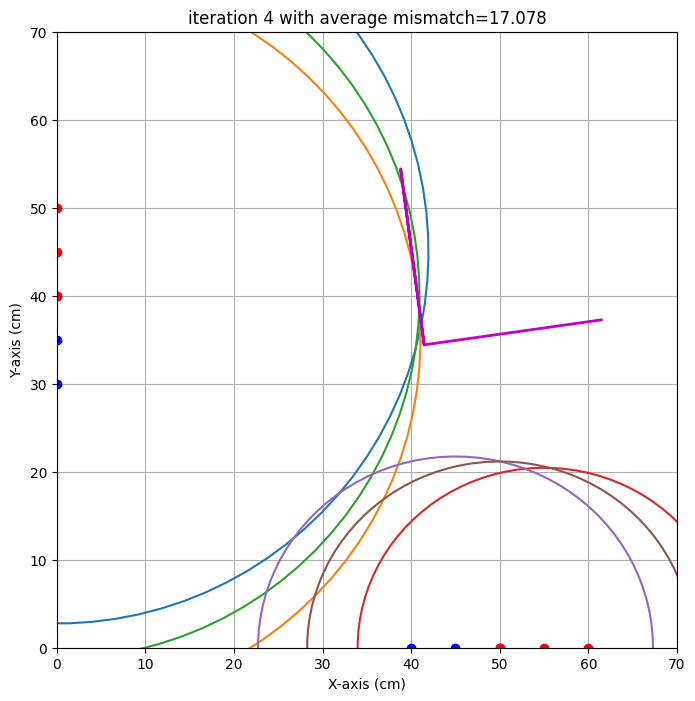

end iteration 4 with average mismatch=17.078


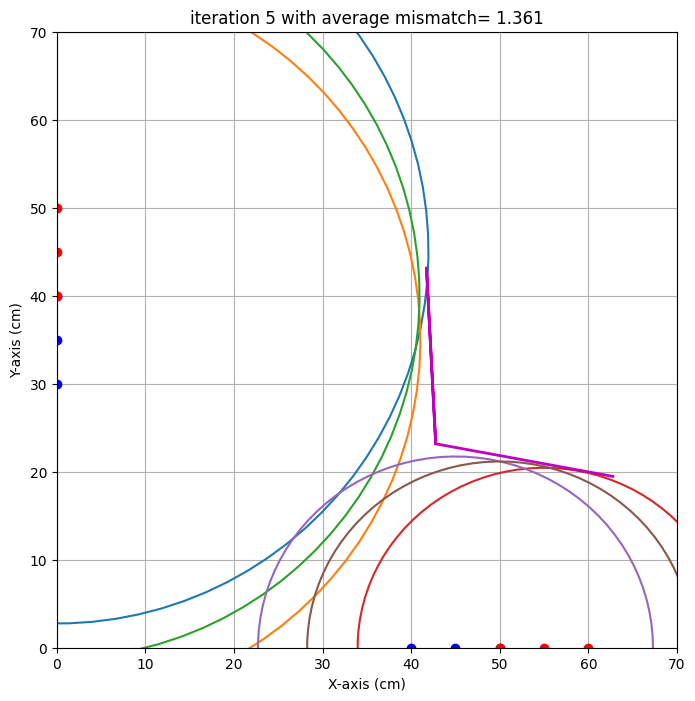

end iteration 5 with average mismatch= 1.361


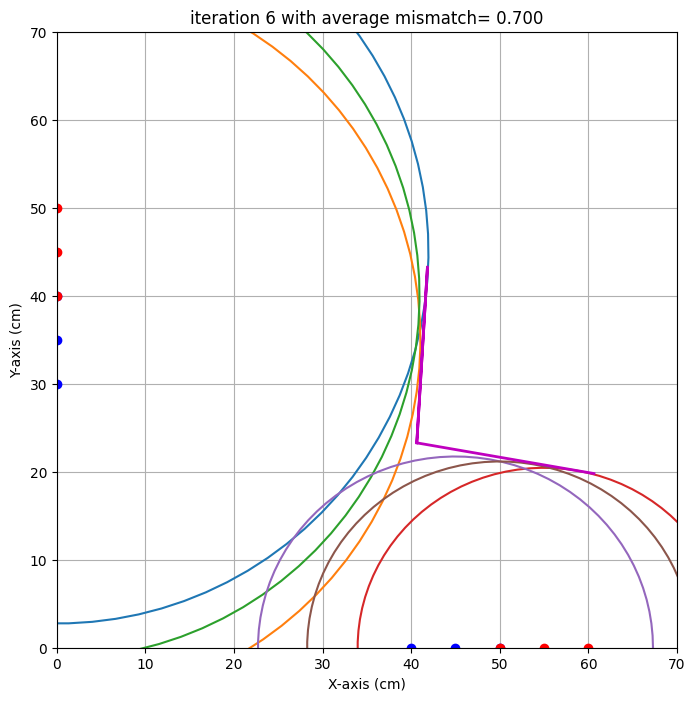

end iteration 6 with average mismatch= 0.700


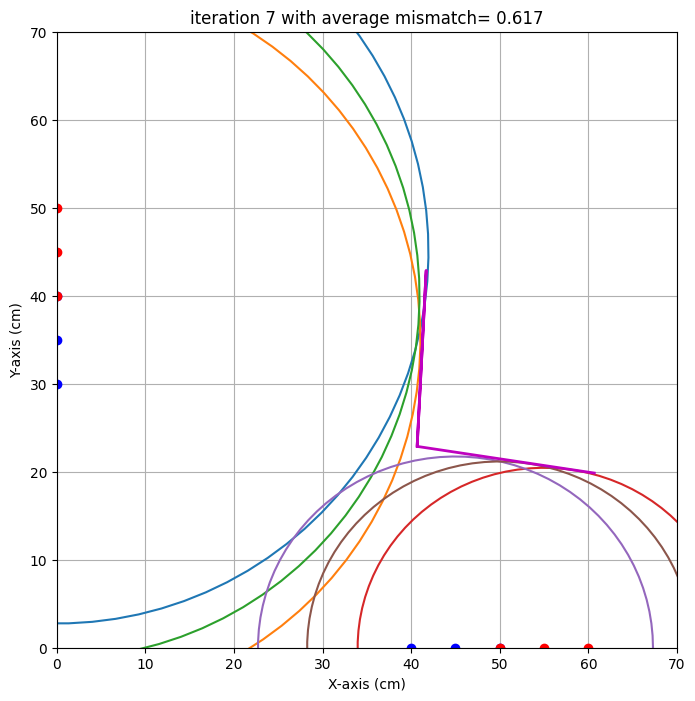

end iteration 7 with average mismatch= 0.617
end iteration 8 with average mismatch= 0.598
end iteration 9 with average mismatch= 0.575


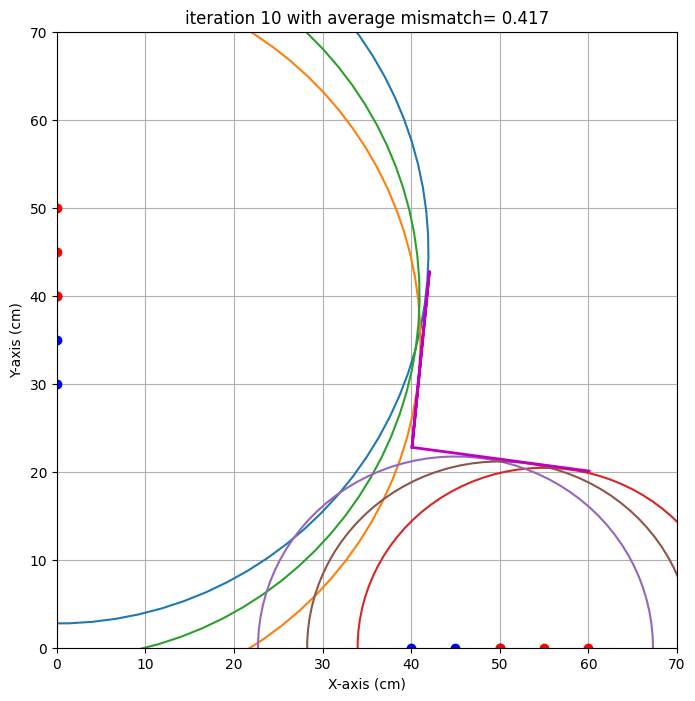

end iteration 10 with average mismatch= 0.417


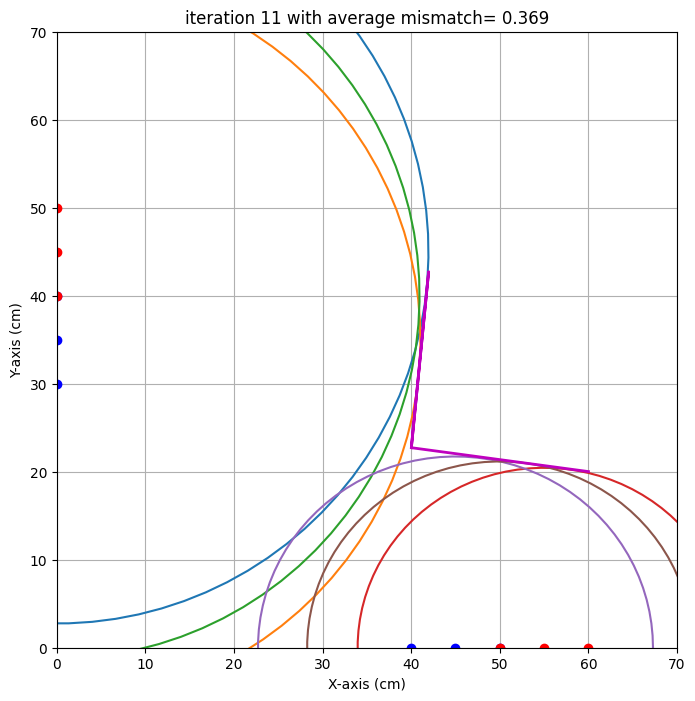

end iteration 11 with average mismatch= 0.369
end iteration 12 with average mismatch= 0.362
end iteration 13 with average mismatch= 0.361
end iteration 14 with average mismatch= 0.361
end iteration 15 with average mismatch= 0.360
end iteration 16 with average mismatch= 0.360
end iteration 17 with average mismatch= 0.360
end iteration 18 with average mismatch= 0.360
end iteration 19 with average mismatch= 0.360
end iteration 20 with average mismatch= 0.360
end iteration 21 with average mismatch= 0.360
end iteration 22 with average mismatch= 0.360
end iteration 23 with average mismatch= 0.360
end iteration 24 with average mismatch= 0.360
end iteration 25 with average mismatch= 0.360
end iteration 26 with average mismatch= 0.360
end iteration 27 with average mismatch= 0.360
end iteration 28 with average mismatch= 0.360
end iteration 29 with average mismatch= 0.360
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little lon

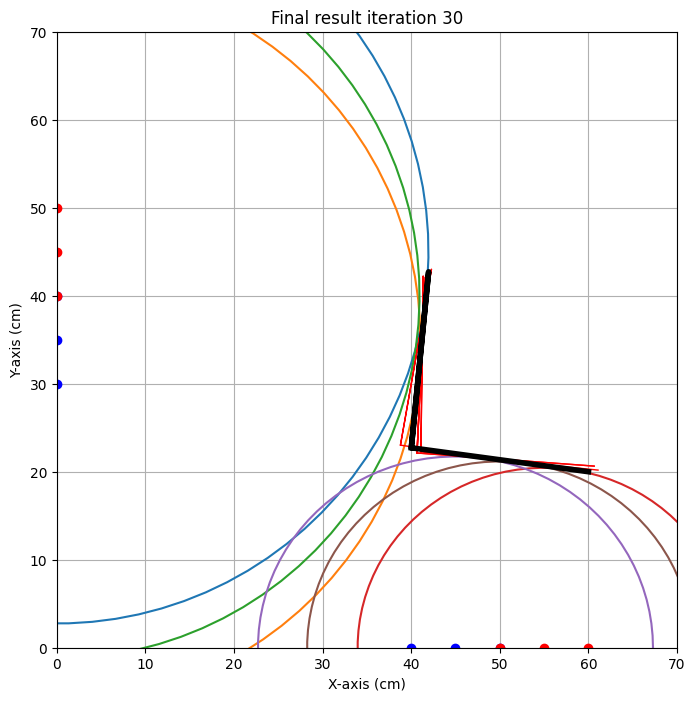

{'alpha': np.float64(-7.744617759531853), 'alpha_eps': np.float64(3.484322923799266), 'beta': np.float64(5.582884239738023), 'beta_eps': np.float64(4.840599362659817), 'x0': np.float64(40.01275286965563), 'x0_eps': np.float64(1.2268749774060126), 'y0': np.float64(22.719995794335425), 'y0_eps': np.float64(0.5921897545429076)}


In [16]:
resultaat = imagingDEF.imagingDEF(dataFinalCheck['Thijn Holswilder'])
print(resultaat)

In [17]:
studentName = 'Thijn Holswilder'

txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt += 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt += 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt += 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'

print(txt.format(
    naam=studentName,
    x0Target=targets['x0'],
    x0=resultaat['x0'],
    x0_eps=resultaat['x0_eps'],
    y0Target=targets['y0'],
    y0=resultaat['y0'],
    y0_eps=resultaat['y0_eps'],
    alphaTarget=targets['alpha'],
    alpha=resultaat['alpha'],
    alpha_eps=resultaat['alpha_eps'],
    betaTarget=targets['beta'],
    beta=resultaat['beta'],
    beta_eps=resultaat['beta_eps']
))

Thijn Holswilder 
x0 target is : 41.0. Gevonden waarde: 40.0 cm met een standaardafwijking van 1.2 cm 
y0 target is : 22.0. Gevonden waarde: 22.7 cm met een standaardafwijking van 0.6 cm 
alpha target is : -13.0. Gevonden waarde: -7.7 graden met een standaardafwijking van 3.5 graad 
beta target is : 6.0. Gevonden waarde: 5.6 graden met een standaardafwijking van 4.8 graad 



## Opdracht 11: Leerdoelen.
Figuur: ![Alt](algoritme1-schets.jpeg "algoritme versie 1")

Figuur: ![Alt](algoritme2-schets.jpeg "algoritme versie 2")

Figuur: ![Alt](algoritme3-schets.jpeg "algoritme versie 3")